# Data Cleaning and Feature Extraction/Engineering

This notebook walks through the EEG preprocessing pipeline step by step,
using a single recording session to illustrate each stage before applying
the full pipeline across all 15 sessions.

The pipeline covers:

- **Loading** raw binary EEG recordings and splitting them into baseline,
  task 1, and task 2 segments using session event timestamps
- **Bandpass filtering** (1–30 Hz) to remove movement and environmental noise
- **Epoch segmentation** into 6-second windows with 3-second stride, along
  with artifact rejection based on amplitude thresholding
- **Feature extraction** via FFT-based band power (theta, alpha, beta) and
  derived features (band ratios, engagement index, frontal alpha asymmetry)
- **Baseline normalization**, dividing each feature by its session-specific
  baseline value to reduce inter-session variability

Each step is visualized on a single session (Session 1) to make the effect
of each transformation concrete, before the same pipeline is applied in a
loop across all 15 sessions to build the final combined dataset
(`all_sessions_normalized.csv`) used in the downstream EDA and modeling
notebooks.

The notebook concludes with a quantitative check on whether baseline
normalization actually reduces session-to-session variability, using the
coefficient of variation (CV) as a metric.

## Data Cleaning and Feature Extraction

### Load data from a single recording session

In [1]:
from pathlib import Path
import pandas as pd
import contextlib, io

PROJECT_ROOT = Path().resolve().parent

from eeg_focus_tracker.data_collection.preprocessing import load_eeg_from_bin

DATA_PATH = PROJECT_ROOT / "data" / "raw_by_session" / "session1_focus_first_20260325_003303.bin"
events_path = PROJECT_ROOT / "data" / "raw_by_session" / "session1_events.csv"
events = pd.read_csv(events_path)
events_dict = dict(zip(events['event'], events['time']))
with contextlib.redirect_stdout(io.StringIO()):
    df_baseline, df_task1, df_task2 = load_eeg_from_bin(DATA_PATH, events_dict)

# Print the number of samples in each task to verify that the data has been loaded correctly
print(f"Task 1 samples: {len(df_task1)}")
print(f"Task 2 samples: {len(df_task2)}")

Task 1 samples: 116266
Task 2 samples: 116169


In [2]:
print(df_task1.head())

             time         TP9         AF7         AF8        TP10
60935  324.860089 -837.890625 -173.339844  182.128906 -487.304688
60936  324.893120 -461.425781 -501.953125  274.414062 -227.050781
60937  324.897026   -1.953125 -919.433594  780.761719  999.023438
60938  324.900933   70.312500  783.691406 -442.871094  763.183594
60939  324.904839 -875.000000  538.574219 -791.503906  624.023438


### Raw EEG Signal

Below visualization shows first 5 sec of Task 1 Raw EEG recordings before filteration.

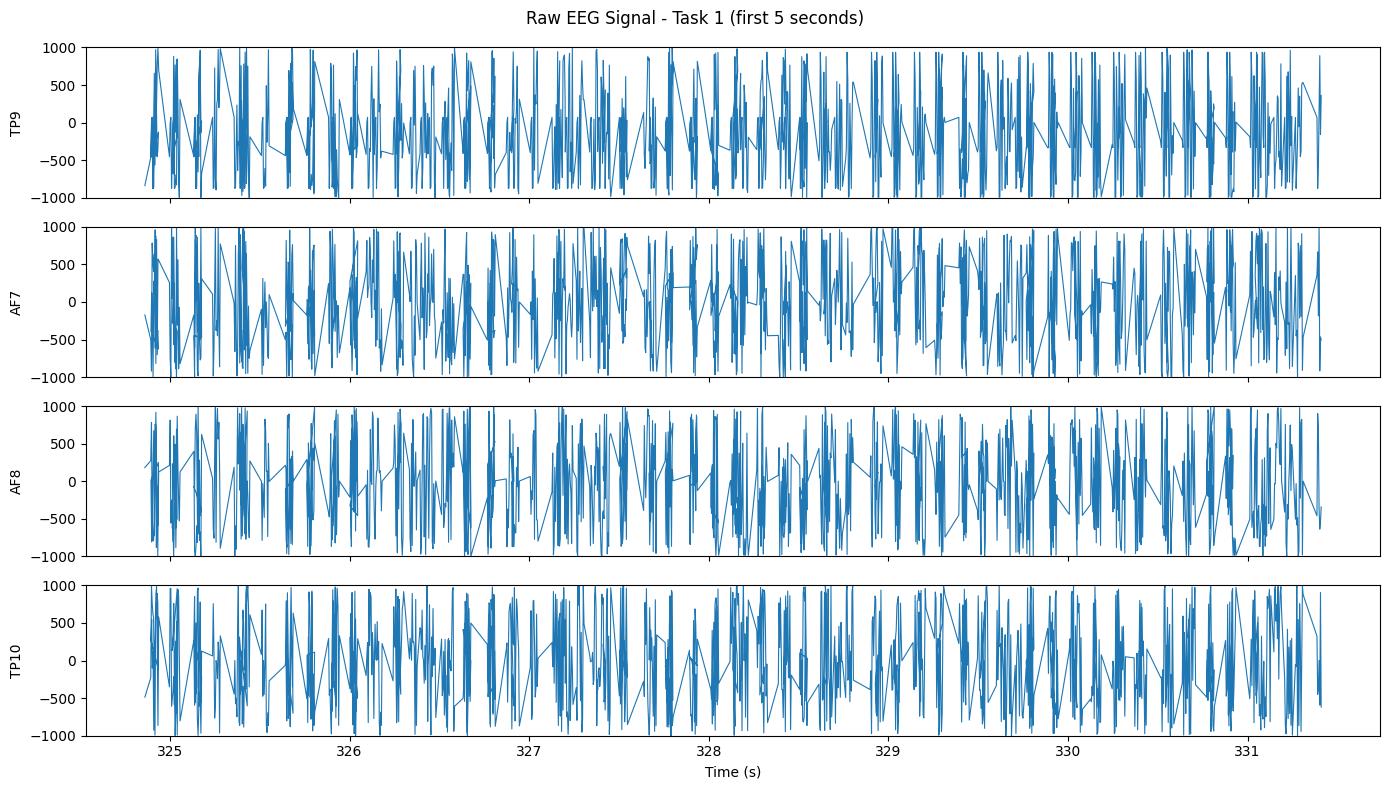

In [3]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(14,8), sharex=True)
channels = ['TP9', 'AF7', 'AF8', 'TP10']
data = df_task1.iloc[:1280]  # first 5 seconds at 256Hz

for ax, ch in zip(axs, channels):
    ax.plot(data['time'], data[ch], linewidth=0.8)
    ax.set_ylabel(ch)
    ax.set_ylim(-1000, 1000)

axs[-1].set_xlabel('Time (s)')
fig.suptitle('Raw EEG Signal - Task 1 (first 5 seconds)')
plt.tight_layout()

### Band Pass Filter (1-30 Hz)

Apply Band Pass Filter (1-30 Hz) to filter out any movement or environmental noises.

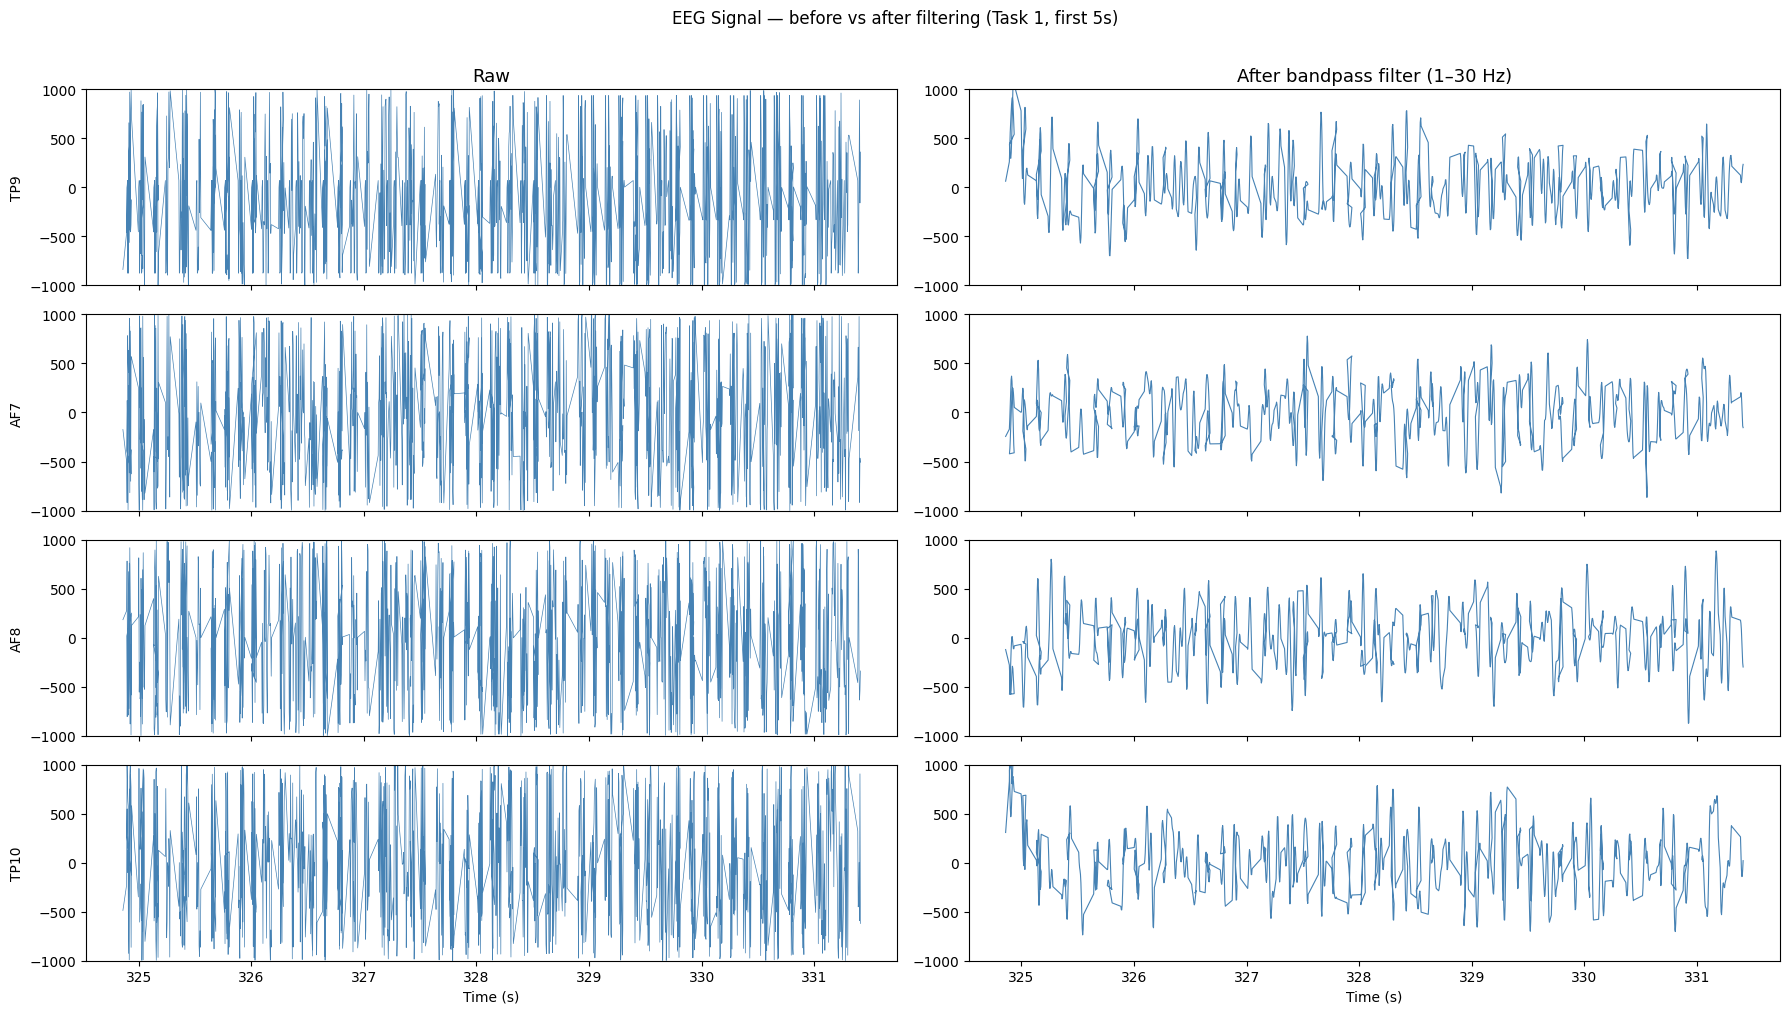

In [4]:
from eeg_focus_tracker.data_collection.preprocessing import band_pass_filter

filtered_task1 = band_pass_filter(df_task1)
data = df_task1.iloc[:1280]
filtered_data = filtered_task1.iloc[:1280] 


fig, axes = plt.subplots(4, 2, figsize=(18, 10), sharex=True)

for i, ch in enumerate(['TP9', 'AF7', 'AF8', 'TP10']):
    # raw
    axes[i, 0].plot(data['time'], data[ch], linewidth=0.5, color='steelblue')
    axes[i, 0].set_ylabel(ch)
    axes[i, 0].set_ylim(-1000, 1000)
    
    # filtered
    axes[i, 1].plot(filtered_data['time'], filtered_data[ch], linewidth=0.8, color='steelblue')
    axes[i, 1].set_ylim(-1000, 1000)

axes[0, 0].set_title('Raw', fontsize=13)
axes[0, 1].set_title('After bandpass filter (1–30 Hz)', fontsize=13)

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

fig.suptitle('EEG Signal — before vs after filtering (Task 1, first 5s)', y=1.01)
plt.tight_layout()


### Epoch Segmentation and Artifact Removal

Separate the datapoints into 6-second windows (epochs) with 3-sec strides for ML training datasets. Remove any epochs if >20% exceeds a threshold to remove noise.

In [5]:
from eeg_focus_tracker.data_collection.preprocessing import create_windows

task1_windows = create_windows(filtered_task1)
task2_windows = create_windows(band_pass_filter(df_task2))
print(f"Task 1 windows: {len(task1_windows)}")
print(f"Task 2 windows: {len(task2_windows)}")

Removal ratio: 0.12
Removal ratio: 0.0
Task 1 windows: 132
Task 2 windows: 150


Threshold value was tested between 200μV to 450μV. 
A threshold of 380 was determined to maintain the removal ratio of training data between 5% to 20% across all recording sessions.

### Band Power Calculation (FFT) and Feature Engineering

In [6]:
from eeg_focus_tracker.data_collection.preprocessing import extract_features

features_task1 = extract_features(task1_windows)
features_task2 = extract_features(task2_windows)
print(features_task1.head())

     TP9_theta     TP9_alpha      TP9_beta  TP9_theta_alpha  TP9_beta_alpha  \
0  8111.338335  11909.442247  46645.100112         0.681085        3.916649   
1  4455.420072   8931.810932  63267.009817         0.498826        7.083335   
2  7226.132939  10309.020970  69981.930172         0.700952        6.788417   
3  6793.499590  11249.095546  58786.124509         0.603915        5.225853   
4  4986.688320  10969.772051  60709.415760         0.454584        5.534246   

   TP9_engagement     AF7_theta     AF7_alpha      AF7_beta  AF7_theta_alpha  \
0        2.329834  13352.894551  13481.519564  33918.443191         0.990459   
1        4.725922  12755.066978  15940.333972  38642.411007         0.800176   
2        3.990950  13301.137377  14425.217674  40092.798484         0.922075   
3        3.258186   9596.912260  10192.130470  34326.534335         0.941600   
4        3.804692   9988.350368  12536.538949  36466.559934         0.796739   

   ...  AF8_theta_alpha  AF8_beta_alpha  AF8

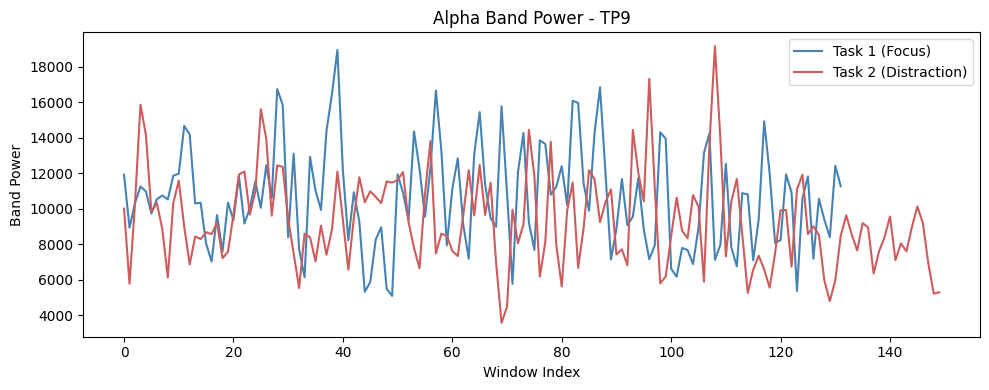

In [7]:
channel = 'TP9'
plt.figure(figsize=(10, 4))
plt.plot(features_task1[channel + '_alpha'], label='Task 1 (Focus)', color='steelblue')
plt.plot(features_task2[channel + '_alpha'], label='Task 2 (Distraction)', color='indianred')
plt.title(f'Alpha Band Power - {channel}')
plt.xlabel('Window Index')
plt.ylabel('Band Power')
plt.legend()
plt.tight_layout()
plt.show()

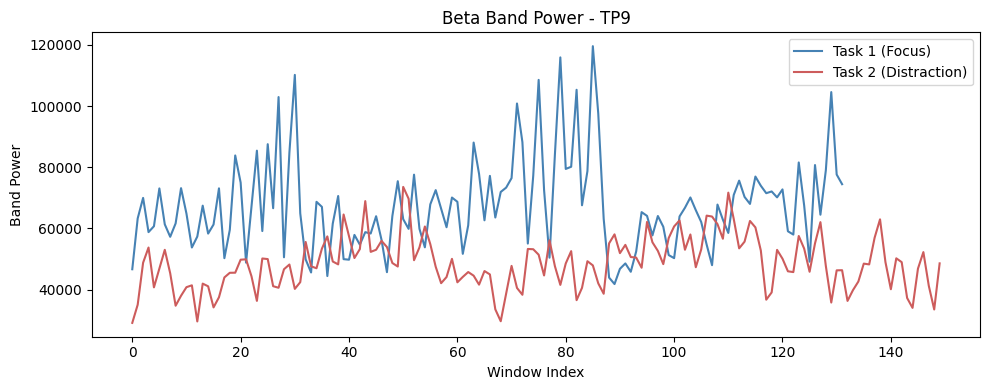

In [8]:
channel = 'TP9'
plt.figure(figsize=(10, 4))
plt.plot(features_task1[channel + '_beta'], label='Task 1 (Focus)', color='steelblue')
plt.plot(features_task2[channel + '_beta'], label='Task 2 (Distraction)', color='indianred')
plt.title(f'Beta Band Power - {channel}')
plt.xlabel('Window Index')
plt.ylabel('Band Power')
plt.legend()
plt.tight_layout()
plt.show()

### Baseline Normalization 

In [9]:
from eeg_focus_tracker.data_collection.preprocessing import normalize_with_baseline, calculate_baseline

baseline_ref = calculate_baseline(df_baseline)
features_task1_norm = normalize_with_baseline(features_task1, baseline_ref)
features_task2_norm = normalize_with_baseline(features_task2, baseline_ref)
print(baseline_ref)

Removal ratio: 0.44594594594594594
TP9_theta            6570.701091
TP9_alpha            9836.049440
TP9_beta            47666.007114
TP9_theta_alpha         0.693052
TP9_beta_alpha          5.041281
TP9_engagement          2.736069
AF7_theta           12909.801665
AF7_alpha           17613.850807
AF7_beta            39280.394854
AF7_theta_alpha         0.810006
AF7_beta_alpha          2.227146
AF7_engagement          1.288129
AF8_theta           11660.613034
AF8_alpha           15284.566740
AF8_beta            40069.243427
AF8_theta_alpha         0.750794
AF8_beta_alpha          2.719126
AF8_engagement          1.542828
TP10_theta          11499.725614
TP10_alpha          13211.720873
TP10_beta           37857.299359
TP10_theta_alpha        0.862056
TP10_beta_alpha         2.954603
TP10_engagement         1.535683
alpha_asymmetry      1928.891984
dtype: float64


In [10]:
def load_all_eeg(directory):
    # Load all CSV files in the specified directory and combine them into a single DataFrame
    directory = Path(directory)
    combined_df = pd.DataFrame()
    for filename in directory.glob('*.csv'):
        df = pd.read_csv(filename, index_col=0)
        session_id = filename.stem  # Extract session ID from filename
        df['session_id'] = session_id
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    return combined_df

In [11]:
all_norm = load_all_eeg(PROJECT_ROOT / "data" / "processed_by_session")
all_norm.head()


,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,AF7_theta_alpha,...,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry,label,session_id,session
0,0.650279,0.657467,1.127051,0.943947,1.660755,1.598751,0.899970,0.696879,0.723869,1.300929,...,0.539417,0.875495,1.085751,0.613941,1.259211,1.521881,-0.897917,1,session9,NaN
1,0.754694,0.894230,1.083241,0.805459,1.173578,1.197501,0.822962,0.795828,0.698131,1.041701,...,0.888803,0.860262,0.948949,1.029510,1.120042,1.114759,-2.933825,1,session9,NaN
2,0.827303,0.694140,0.927814,1.137469,1.294941,1.155275,0.810636,0.872735,0.760590,0.935677,...,1.225121,1.020949,1.123007,1.195724,1.116864,1.038299,-0.143210,1,session9,NaN
3,1.053054,0.614274,1.065218,1.636101,1.680012,1.260832,0.734686,1.478967,0.945023,0.500410,...,1.485533,0.782991,1.187742,1.890520,1.540236,1.122495,9.351544,1,session9,NaN
4,1.505923,0.779683,1.006780,1.843345,1.250987,0.880731,0.802078,1.228955,1.067125,0.657450,...,1.015730,1.128613,1.100621,0.896786,0.990181,1.044382,4.628821,1,session9,NaN


In [12]:
import glob
import os

DATA_DIR = PROJECT_ROOT / "data" / "raw_by_session"
all_sessions_features = []

for session_id in range(1, 16):  # session1 〜 session15
    
    # get file path
    bin_files    = glob.glob(os.path.join(DATA_DIR, f"session{session_id}_*.bin"))
    events_files = glob.glob(os.path.join(DATA_DIR, f"session{session_id}_events.csv"))

    if not bin_files or not events_files:
        print(f"session{session_id}: File Not Found - Skipped")
        continue

    bin_path    = bin_files[0]
    events_path = events_files[0]

    # label task condition based on the session number
    if session_id % 2 != 0:
        task1_label, task2_label = 1, 0  # focus_first
    else:
        task1_label, task2_label = 0, 1  # distraction_first

    # load events
    events = pd.read_csv(events_path)
    events_dict = dict(zip(events['event'], events['time']))

    # preprocessing
    with contextlib.redirect_stdout(io.StringIO()):
        df_baseline, df_task1, df_task2 = load_eeg_from_bin(bin_path, events_dict)
        baseline_ref = calculate_baseline(df_baseline)

        for df_task, label in [(df_task1, task1_label), (df_task2, task2_label)]:
            df_filt  = band_pass_filter(df_task)
            windows  = create_windows(df_filt)
            features = extract_features(windows)
            features_norm = normalize_with_baseline(features, baseline_ref)
            features_norm['label']   = label
            features_norm['session'] = session_id
            all_sessions_features.append(features_norm)


# merge and save
all_norm = pd.concat(all_sessions_features, ignore_index=True)
all_norm.head()

,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,AF7_theta_alpha,...,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry,label,session
0,1.234471,1.210795,0.978582,0.982733,0.776915,0.851526,1.034322,0.765393,0.863495,1.222779,...,1.181369,1.001467,1.176479,1.089762,0.859498,0.898335,0.992781,-0.554765,1,1
1,0.678074,0.908069,1.327298,0.719753,1.405066,1.727267,0.988014,0.904989,0.983758,0.987863,...,1.013922,0.856766,0.952863,0.925597,0.907871,0.942069,1.016758,1.395709,1,1
2,1.099751,1.048086,1.468173,1.011400,1.346566,1.458644,1.030313,0.818970,1.020682,1.138356,...,0.987976,0.751295,0.777029,1.040647,0.976261,1.298846,1.356943,1.950642,1,1
3,1.033908,1.143660,1.233292,0.871385,1.036612,1.190827,0.743382,0.578643,0.873885,1.162460,...,0.700564,0.878124,0.996854,1.010756,0.889440,0.983345,1.070851,-3.202137,1,1
4,0.758928,1.115262,1.273642,0.655917,1.097786,1.390569,0.773703,0.711743,0.928365,0.983621,...,1.030596,0.823808,1.215817,0.876779,0.684149,0.699380,0.846399,-0.242200,1,1


In [13]:
all_sessions_features = []

for session_id in range(1, 16):  # session1 〜 session15
    
    # get file path
    bin_files    = glob.glob(os.path.join(DATA_DIR, f"session{session_id}_*.bin"))
    events_files = glob.glob(os.path.join(DATA_DIR, f"session{session_id}_events.csv"))

    if not bin_files or not events_files:
        print(f"session{session_id}: File Not Found - Skipped")
        continue

    bin_path    = bin_files[0]
    events_path = events_files[0]

    # label task condition based on the session number
    if session_id % 2 != 0:
        task1_label, task2_label = 1, 0  # focus_first
    else:
        task1_label, task2_label = 0, 1  # distraction_first

    # load events
    events = pd.read_csv(events_path)
    events_dict = dict(zip(events['event'], events['time']))

    # preprocessing
    with contextlib.redirect_stdout(io.StringIO()):
        df_baseline, df_task1, df_task2 = load_eeg_from_bin(bin_path, events_dict)

        for df_task, label in [(df_task1, task1_label), (df_task2, task2_label)]:
            df_filt  = band_pass_filter(df_task)
            windows  = create_windows(df_filt)
            features = extract_features(windows)
            features['label']   = label
            features['session'] = session_id
            all_sessions_features.append(features)


# merge and save
all_without_norm = pd.concat(all_sessions_features, ignore_index=True)
all_without_norm.head()

,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,AF7_theta_alpha,...,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry,label,session
0,8111.338335,11909.442247,46645.100112,0.681085,3.916649,2.329834,13352.894551,13481.519564,33918.443191,0.990459,...,1.822650,11516.597927,15543.312081,41255.428189,0.740936,2.654224,1.524596,-1070.081270,1,1
1,4455.420072,8931.810932,63267.009817,0.498826,7.083335,4.725922,12755.066978,15940.333972,38642.411007,0.800176,...,1.564308,9852.570272,12588.962756,35040.611330,0.782636,2.783439,1.561418,2692.171294,1,1
2,7226.132939,10309.020970,69981.930172,0.700952,6.788417,3.990950,13301.137377,14425.217674,40092.798484,0.922075,...,1.524278,8639.684733,10265.883969,39396.078158,0.841592,3.837573,2.083835,3762.578570,1,1
3,6793.499590,11249.095546,58786.124509,0.603915,5.225853,3.258186,9596.912260,10192.130470,34326.534335,0.941600,...,1.080849,10098.185099,13170.155542,38264.505502,0.766748,2.905395,1.644488,-6176.576512,1,1
4,4986.688320,10969.772051,60709.415760,0.454584,5.534246,3.804692,9988.350368,12536.538949,36466.559934,0.796739,...,1.590033,9473.569409,16063.037342,33192.492998,0.589774,2.066390,1.299800,-467.177430,1,1


In [14]:
print("=== Variability Comparison across Sessions（TP9_alpha） ===")

raw_medians  = all_without_norm.groupby('session')['TP9_alpha'].median()
norm_medians = all_norm.groupby('session')['TP9_alpha'].median()

cv_raw  = raw_medians.std()  / raw_medians.mean()
cv_norm = norm_medians.std() / norm_medians.mean()

print(f"Before normalization  CV: {cv_raw:.3f}")
print(f"After normalization  CV: {cv_norm:.3f}")
print(f"Rate of Improvement: {(cv_raw - cv_norm) / cv_raw * 100:.1f}%")

=== Variability Comparison across Sessions（TP9_alpha） ===
Before normalization  CV: 0.112
After normalization  CV: 0.077
Rate of Improvement: 31.4%


In [15]:
all_norm.to_csv("../data/processed_by_session/all_sessions_normalized.csv", index=False)